## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [33]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [34]:
import warnings
warnings.filterwarnings('ignore')

In [35]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [36]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_2023-May-1st_filled.csv', encoding=enc)


In [37]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,αγιας,θεσσαλιας,22.63715,39.66477,2023-05-01,2023,5,2023-04-30,39.662866,22.635299,0.320605,0.010753,-0.297699,-0.010753,0.505039,0.205061,-0.442851,-0.205061,0.125752,0.119283,0.096853,0.119283,2023-05-01,39.662866,22.635299,14966.0,14353.0,39.662866,22.635299,14219.000000,13818.000000,14307.062500,13704.263158,14637.352941,13943.333333,14850.466667,14041.625000,2023-05-01,39.650181,22.650104,70.551421,2023-04-24,2023-04-17,2023-04-24,2023-04-17,0.462882,28.530567
1,αγιας,θεσσαλιας,22.70702,39.75460,2023-05-01,2023,5,2023-04-30,39.752697,22.707165,0.506922,0.087536,-0.458373,-0.087536,0.521654,0.109084,-0.459319,-0.109084,0.056933,0.073780,0.034842,0.073780,2023-05-01,39.752697,22.707165,14569.0,14025.0,39.752697,22.707165,14223.600000,13741.846154,14084.133333,13737.714286,14400.923077,13793.692308,14395.000000,13897.142857,2023-05-01,39.750182,22.750104,80.850409,2023-04-24,2023-04-17,2023-04-24,2023-04-17,2.064366,13.038493
2,αγιας,θεσσαλιας,22.73031,39.79054,2023-05-01,2023,5,2023-04-30,39.788630,22.729622,0.398340,-0.021568,-0.405003,0.021568,0.148230,0.267161,-0.058763,-0.267161,0.041401,0.077481,0.012572,0.077481,2023-05-01,39.788630,22.729622,14419.0,13927.0,39.788630,22.729622,14031.307692,13745.444444,13840.846154,13747.428571,14317.428571,13781.400000,14333.600000,13838.888889,2023-05-01,39.750182,22.750104,80.850409,2023-04-24,2023-04-17,2023-04-24,2023-04-17,2.064366,13.038493
3,αγιας,θεσσαλιας,22.77688,39.66477,2023-05-01,2023,5,2023-04-30,39.662866,22.779030,0.659985,0.255662,-0.558361,-0.255662,0.666750,0.288541,-0.556839,-0.288541,0.021385,0.034793,0.019709,0.034793,2023-05-01,39.662866,22.779030,14859.0,14292.0,39.662866,22.779030,14166.800000,13831.857143,14232.187500,13729.571429,14586.642857,13952.500000,14702.571429,14088.285714,2023-05-01,39.650181,22.750104,76.251762,2023-04-24,2023-04-17,2023-04-24,2023-04-17,4.479433,30.095222
4,αγιας,θεσσαλιας,22.77688,39.70070,2023-05-01,2023,5,2023-04-30,39.698798,22.779030,0.510698,0.199188,-0.470016,-0.199188,0.579717,0.203453,-0.511025,-0.203453,0.036495,0.035902,0.025967,0.035902,2023-05-01,39.698798,22.779030,14881.0,14298.0,39.698798,22.779030,14235.545455,13809.769231,14269.294118,13762.076923,14640.357143,13945.142857,14705.153846,14098.000000,2023-05-01,39.750182,22.750104,80.850409,2023-04-24,2023-04-17,2023-04-24,2023-04-17,2.064366,13.038493


In [38]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [39]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [40]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [41]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας,θεσσαλιας,22.63715,39.66477,2023-05-01,2023,5,0.320605,0.010753,-0.297699,-0.010753,0.505039,0.205061,-0.442851,-0.205061,0.125752,0.119283,0.096853,0.119283,14966.0,14353.0,14219.000000,13818.000000,14307.062500,13704.263158,14637.352941,13943.333333,14850.466667,14041.625000,70.551421,0.462882,28.530567
1,αγιας,θεσσαλιας,22.70702,39.75460,2023-05-01,2023,5,0.506922,0.087536,-0.458373,-0.087536,0.521654,0.109084,-0.459319,-0.109084,0.056933,0.073780,0.034842,0.073780,14569.0,14025.0,14223.600000,13741.846154,14084.133333,13737.714286,14400.923077,13793.692308,14395.000000,13897.142857,80.850409,2.064366,13.038493
2,αγιας,θεσσαλιας,22.73031,39.79054,2023-05-01,2023,5,0.398340,-0.021568,-0.405003,0.021568,0.148230,0.267161,-0.058763,-0.267161,0.041401,0.077481,0.012572,0.077481,14419.0,13927.0,14031.307692,13745.444444,13840.846154,13747.428571,14317.428571,13781.400000,14333.600000,13838.888889,80.850409,2.064366,13.038493
3,αγιας,θεσσαλιας,22.77688,39.66477,2023-05-01,2023,5,0.659985,0.255662,-0.558361,-0.255662,0.666750,0.288541,-0.556839,-0.288541,0.021385,0.034793,0.019709,0.034793,14859.0,14292.0,14166.800000,13831.857143,14232.187500,13729.571429,14586.642857,13952.500000,14702.571429,14088.285714,76.251762,4.479433,30.095222
4,αγιας,θεσσαλιας,22.77688,39.70070,2023-05-01,2023,5,0.510698,0.199188,-0.470016,-0.199188,0.579717,0.203453,-0.511025,-0.203453,0.036495,0.035902,0.025967,0.035902,14881.0,14298.0,14235.545455,13809.769231,14269.294118,13762.076923,14640.357143,13945.142857,14705.153846,14098.000000,80.850409,2.064366,13.038493


In [42]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2023-05-01,αγιας,θεσσαλιας,22.750267,39.710970,2023.0,5.0,0.509207,0.119405,-0.451816,-0.119405,0.531592,0.254587,-0.428750,-0.254587,0.077768,0.058778,0.056475,0.058778,14608.285714,14153.000000,14158.229570,13810.607919,14132.381348,13770.111663,14483.438175,13900.012383,14528.540407,14007.143707,76.675988,2.381410,17.837466
1,2023-05-01,αλμυρου,θεσσαλιας,22.692366,39.136391,2023.0,5.0,0.645191,0.302370,-0.529492,-0.302370,0.618919,0.280067,-0.511682,-0.280067,0.056373,0.054701,0.034039,0.054701,14633.444444,14200.333333,14236.213555,13871.070700,14235.830525,13815.772792,14503.039805,14000.498550,14640.452078,14072.106614,208.946587,3.480882,69.269711
2,2023-05-01,αλοννησου,θεσσαλιας,24.073790,39.328960,2023.0,5.0,0.493058,0.137236,-0.431136,-0.137236,0.499103,0.137082,-0.425521,-0.137082,0.036059,0.052143,0.019232,0.052143,14533.000000,14299.000000,14303.111111,14120.666667,14247.800000,14074.285714,14424.133333,14144.066667,14543.000000,14215.666667,163.677945,7.946645,55.220344
3,2023-05-01,αργιθεας,θεσσαλιας,21.430513,39.221380,2023.0,5.0,0.597637,0.302454,-0.493106,-0.302454,0.560003,0.257320,-0.465701,-0.257320,0.040313,0.053018,0.024440,0.053018,14526.000000,13953.000000,13984.796537,13767.640659,13972.290278,13581.276389,14264.541026,13850.111111,14318.077381,13868.033333,141.474393,8.412601,10.754827
4,2023-05-01,βολου,θεσσαλιας,22.883800,39.351977,2023.0,5.0,0.510673,0.128033,-0.451844,-0.128033,0.513199,0.149993,-0.449576,-0.149993,0.048106,0.049815,0.032318,0.049815,14920.000000,14251.333333,14310.624820,13874.456288,14320.436508,13834.927778,14589.631410,13978.820513,14708.583333,14067.142857,146.622452,1.161971,49.566698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,2023-05-01,τεμπων,θεσσαλιας,22.553160,39.852112,2023.0,5.0,0.480148,0.146282,-0.406046,-0.146282,0.482391,0.136832,-0.414499,-0.136832,0.056086,0.063591,0.039908,0.063591,14615.200000,14143.000000,14131.844872,13769.820000,14115.170075,13710.264791,14425.669118,13892.648535,14496.147902,13987.089286,58.330156,1.604215,14.232823
21,2023-05-01,τρικκαιων,θεσσαλιας,21.797560,39.635058,2023.0,5.0,0.549746,0.172030,-0.490626,-0.172030,0.581852,0.193943,-0.505295,-0.193943,0.065187,0.075038,0.041146,0.075038,14875.600000,14030.200000,14191.183077,13785.802381,14353.424316,13765.126176,14621.389846,13986.928283,14689.561490,14047.238095,136.919840,6.316782,12.798308
22,2023-05-01,τυρναβου,θεσσαλιας,22.343000,39.828472,2023.0,5.0,0.535068,0.234040,-0.454530,-0.234040,0.550848,0.197866,-0.473108,-0.197866,0.062092,0.064908,0.048927,0.064908,14770.750000,14176.750000,14205.631944,13756.379121,14250.387054,13720.940664,14569.709428,13922.793269,14687.921314,14042.280258,51.931327,1.330120,15.736819
23,2023-05-01,φαρκαδονας,θεσσαλιας,22.020557,39.603750,2023.0,5.0,0.476323,0.093934,-0.445219,-0.093934,0.511657,0.142931,-0.466496,-0.142931,0.079564,0.078632,0.046201,0.078632,14845.333333,14292.333333,14179.025000,13814.481685,14325.770833,13813.812500,14609.167725,14019.155400,14719.909041,14095.839286,94.381480,5.099200,21.808518


In [43]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [44]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [45]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [46]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [47]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [48]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'THESSALY'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [49]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [50]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

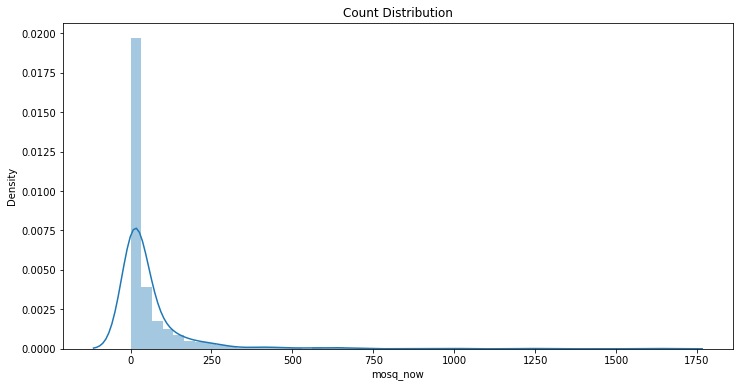

In [51]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [52]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

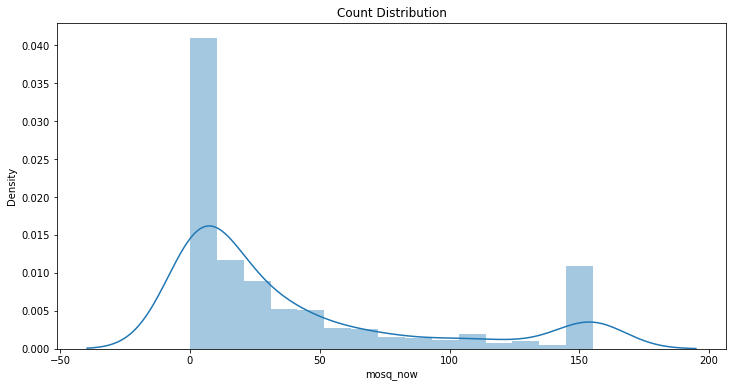

In [53]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

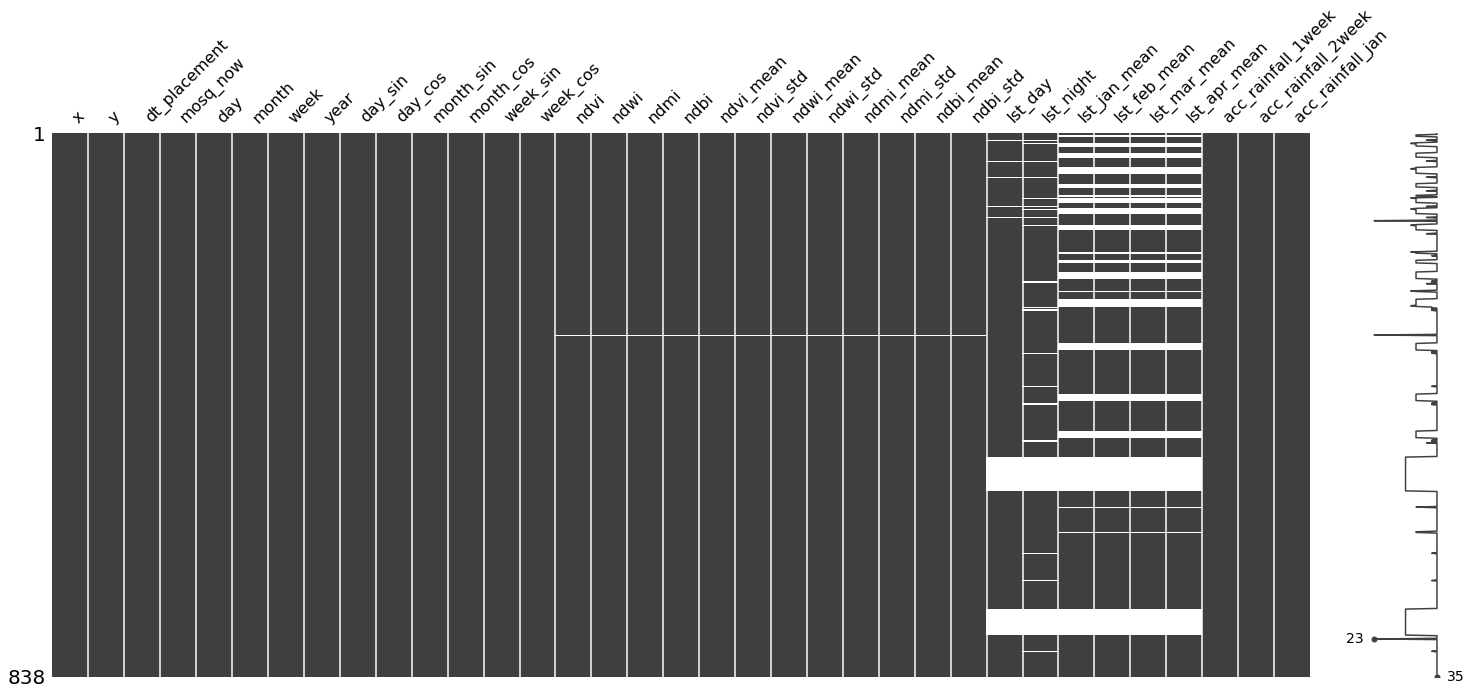

In [54]:
missingno.matrix(mosquito_data_nuts2)

In [55]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [56]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

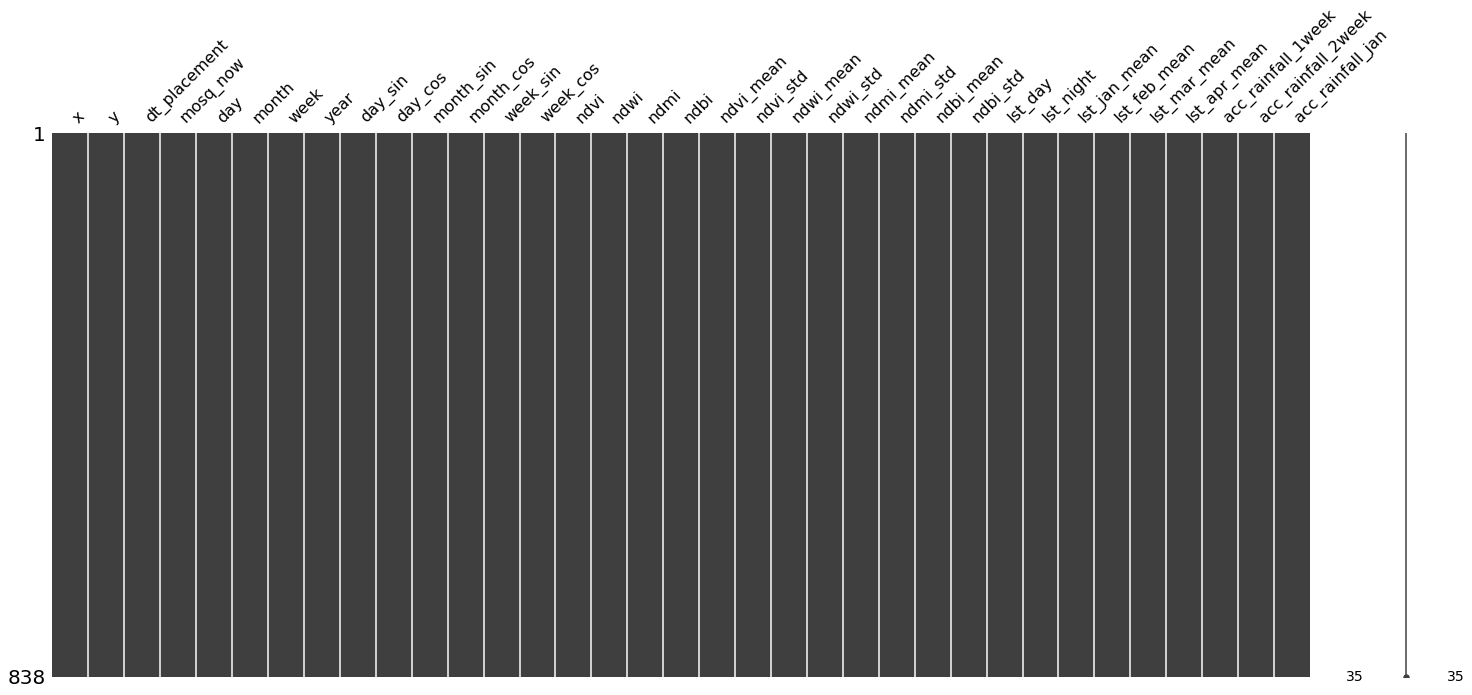

In [57]:
missingno.matrix(mosquito_data_nuts2)

In [58]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [59]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.   16.5 155.3]


In [60]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 43.06512 | Val Loss: 31.84540 | Train Acc: 4.592| Val Acc: 3.870
Epoch 002: | Train Loss: 39.81471 | Val Loss: 31.06592 | Train Acc: 4.107| Val Acc: 3.715
Epoch 003: | Train Loss: 36.65372 | Val Loss: 31.00864 | Train Acc: 3.519| Val Acc: 3.707
Epoch 004: | Train Loss: 34.97181 | Val Loss: 27.91369 | Train Acc: 3.101| Val Acc: 3.318
Epoch 005: | Train Loss: 34.36368 | Val Loss: 25.85144 | Train Acc: 2.926| Val Acc: 2.741
Epoch 006: | Train Loss: 33.35244 | Val Loss: 24.29924 | Train Acc: 2.794| Val Acc: 2.489
Epoch 007: | Train Loss: 33.07722 | Val Loss: 23.42073 | Train Acc: 2.681| Val Acc: 2.188
Epoch 008: | Train Loss: 32.97225 | Val Loss: 23.52400 | Train Acc: 2.666| Val Acc: 2.139
Epoch 009: | Train Loss: 32.80628 | Val Loss: 23.16129 | Train Acc: 2.635| Val Acc: 1.951
Epoch 010: | Train Loss: 32.69350 | Val Loss: 22.91543 | Train Acc: 2.635| Val Acc: 1.578
Epoch 011: | Train Loss: 32.47260 | Val Loss: 22.96524 | Train Acc: 2.687| Val Acc: 1.595
Epoch 012:

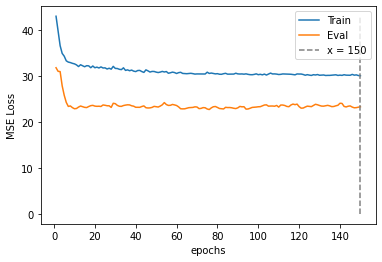

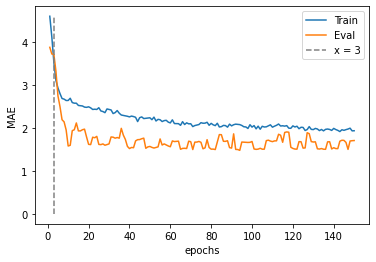

In [61]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [62]:
metrics(train, test, threshold=30)

MAE on train set:  19.99085819142014
min prediction: 1
max prediction: 183

MAE on test set:  26.42061105063263
Error ⩽ 30: 68.70 %
min prediction: 1
max prediction: 216


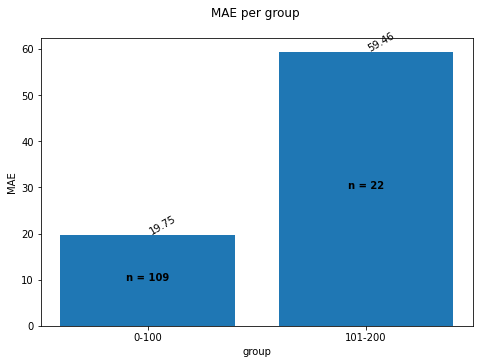

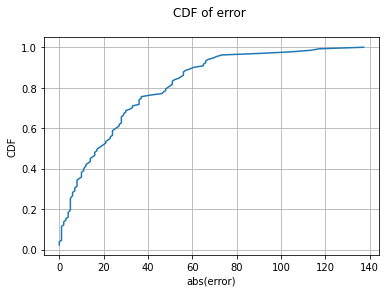

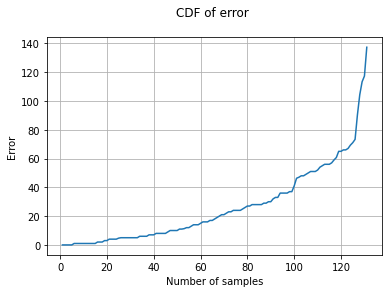

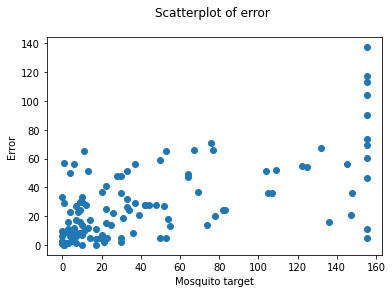

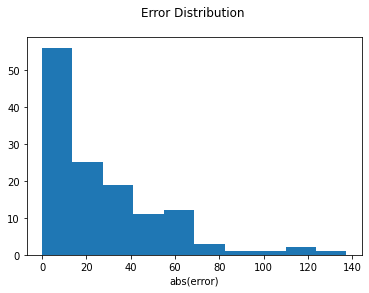

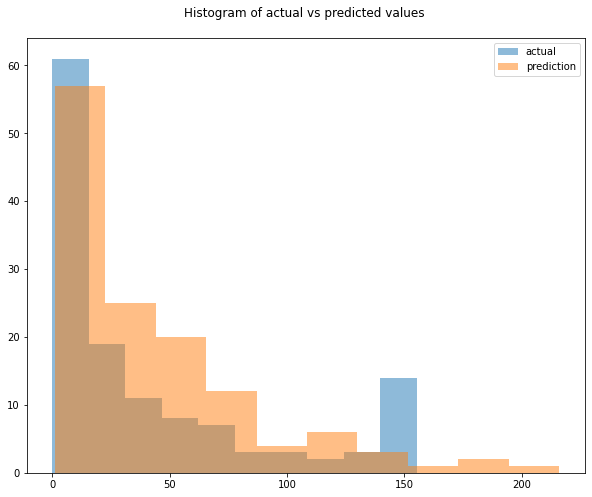

In [63]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 33.88364 | Val Loss: 0.05425 | Train Acc: 2.389| Val Acc: 0.045
Epoch 002: | Train Loss: 33.44301 | Val Loss: 0.03154 | Train Acc: 2.360| Val Acc: 0.045
Epoch 003: | Train Loss: 33.15195 | Val Loss: 0.00319 | Train Acc: 2.258| Val Acc: 0.045
Epoch 004: | Train Loss: 33.09239 | Val Loss: 0.00311 | Train Acc: 2.241| Val Acc: 0.045
Epoch 005: | Train Loss: 32.73303 | Val Loss: 0.00155 | Train Acc: 2.190| Val Acc: 0.045
Epoch 006: | Train Loss: 32.84476 | Val Loss: 0.00054 | Train Acc: 2.182| Val Acc: 0.045
Epoch 007: | Train Loss: 32.73884 | Val Loss: 0.00006 | Train Acc: 2.210| Val Acc: 0.045
Epoch 008: | Train Loss: 32.68404 | Val Loss: 0.00153 | Train Acc: 2.199| Val Acc: 0.045
Epoch 009: | Train Loss: 32.65709 | Val Loss: 0.00001 | Train Acc: 2.195| Val Acc: 0.045
Epoch 010: | Train Loss: 32.42673 | Val Loss: 0.00286 | Train Acc: 2.146| Val Acc: 0.045
Epoch 011: | Train Loss: 32.44623 | Val Loss: 0.00189 | Train Acc: 2.149| Val Acc: 0.045
Epoch 012: | Train Lo

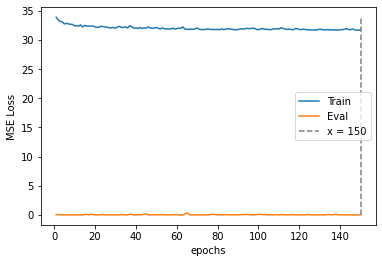

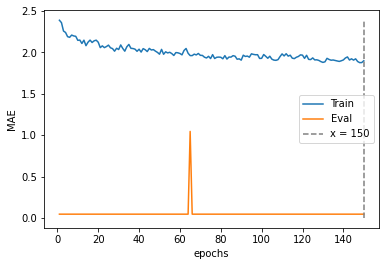

In [64]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [65]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [66]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [67]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [68]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [69]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [70]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

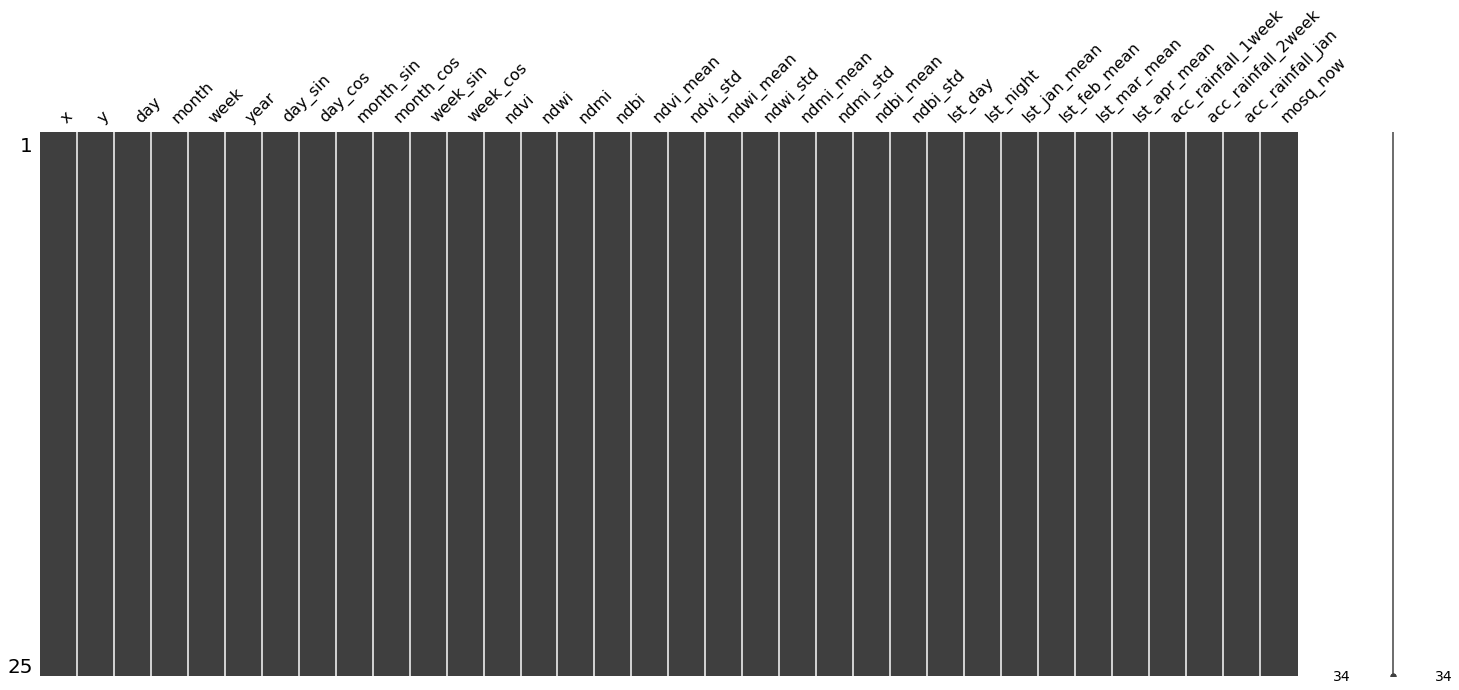

In [71]:
missingno.matrix(dataset_mamoth)

In [72]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [73]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [74]:
predictions = give_predictions(model, dataset_mamoth)

In [75]:
mosqutio_predictions['mosq_pred'] = predictions

In [76]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.750267,39.710970,2023-05-01,19
1,22.692366,39.136391,2023-05-01,4
2,24.073790,39.328960,2023-05-01,1
3,21.430513,39.221380,2023-05-01,18
4,22.883800,39.351977,2023-05-01,68
...,...,...,...,...
20,22.553160,39.852112,2023-05-01,32
21,21.797560,39.635058,2023-05-01,29
22,22.343000,39.828472,2023-05-01,29
23,22.020557,39.603750,2023-05-01,51


In [77]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2023-May-1st.csv', index = False)